# UCI Adult Census — a real-world fair-learning benchmark

Every fairness-constrained learning method eventually has to prove itself on the **UCI Adult Census Income** dataset. It is the canonical tabular benchmark for algorithmic fairness: 32,000 people, fourteen demographic and economic features, and a binary label for whether their income exceeds \$50K. Two sensitive attributes are built into the schema — gender and race — and both correlate strongly with income in the raw data. Any off-the-shelf classifier will pick up on those correlations.

This notebook ports a classic worked example onto `FairModelWrapper`. The source is a Spanish-language TensorFlow tutorial by Valero Laparra that solves the problem with a hand-rolled `GradientTape` training loop and an `|Pearson correlation|` penalty. We keep the *exact same* network architecture, the *exact same* data pipeline, and swap only two things:

1. The hand-rolled training loop → standard `compile` / `fit`.
2. The linear Pearson correlation penalty → **CKA**, a nonlinear dependence measure that catches structure that absolute correlation cannot.

Nothing else changes. That is the point of the wrapper.

**What you will see**

1. The raw unfairness of the data: women are ~3× less likely than men to have high income in this sample.
2. A baseline Keras MLP that faithfully reproduces that bias in its predictions.
3. The same MLP wrapped with `FairModelWrapper`, trained with CKA, producing predictions whose dependence on gender is nearly zero.
4. A $\mu$ sweep quantifying the cost of fairness: how much accuracy you pay per unit of decoupling from the sensitive attribute.
5. A small sidebar showing why CKA is a strictly richer measure than Pearson correlation.

In [1]:
from __future__ import annotations

import csv
import os

os.environ["KERAS_BACKEND"] = "jax"

import keras
import matplotlib.pyplot as plt
import numpy as np

from _style import style_ax
from fairkl.metrics.cka import CKALoss, cka_rbf
from fairkl.models import FairModelWrapper

## Data: download + preprocess

The dataset is mirrored as a CSV by Google's MLCC project. We download it once (`keras.utils.get_file` caches to `~/.keras/`), parse with the standard library's `csv` module, and keep the five numeric / encoded features the original notebook used:

- `age` — continuous
- `education_num` — an ordinal count of years of education
- `race` — categorical, five levels, encoded as 0–4
- `gender` — binary (0 = Male, 1 = Female)
- `hours_per_week` — continuous

Target: `income_bracket` → 1 if `>50K`, 0 otherwise. The three continuous columns are z-standardised; binary and ordinal columns are left as is.

In [2]:
URL_TRAIN = "https://download.mlcc.google.com/mledu-datasets/adult_census_train.csv"
URL_TEST = "https://download.mlcc.google.com/mledu-datasets/adult_census_test.csv"

COLUMNS = [
    "age",
    "workclass",
    "fnlwgt",
    "education",
    "education_num",
    "marital_status",
    "occupation",
    "relationship",
    "race",
    "gender",
    "capital_gain",
    "capital_loss",
    "hours_per_week",
    "native_country",
    "income_bracket",
]

RACE_LEVELS = ["White", "Asian-Pac-Islander", "Amer-Indian-Eskimo", "Other", "Black"]
GENDER_LEVELS = ["Male", "Female"]


def load_adult(csv_path: str, skip_header: bool) -> np.ndarray:
    """Parse the Adult CSV into a numpy array of (n, 6) with columns
    [age, education_num, race, gender, hours_per_week, income_bracket]."""
    rows = []
    with open(csv_path, newline="") as f:
        reader = csv.reader(f, skipinitialspace=True)
        if skip_header:
            next(reader)
        for r in reader:
            if len(r) < 15 or "?" in r:
                continue
            d = dict(zip(COLUMNS, r, strict=True))
            try:
                race_idx = RACE_LEVELS.index(d["race"])
                gender_idx = GENDER_LEVELS.index(d["gender"])
                # income_bracket is ">50K" on train, ">50K." on test
                income = 1 if d["income_bracket"].rstrip(".") == ">50K" else 0
            except (ValueError, KeyError):
                continue
            rows.append(
                [
                    float(d["age"]),
                    float(d["education_num"]),
                    float(race_idx),
                    float(gender_idx),
                    float(d["hours_per_week"]),
                    float(income),
                ]
            )
    return np.asarray(rows, dtype="float32")


train_csv = keras.utils.get_file("adult_census_train.csv", URL_TRAIN)
test_csv = keras.utils.get_file("adult_census_test.csv", URL_TEST)

train_raw = load_adult(train_csv, skip_header=False)
test_raw = load_adult(test_csv, skip_header=True)

# Standardise continuous columns (age, education_num, hours_per_week) using
# train-set statistics only — do not leak test distribution into training.
for col in (0, 1, 4):
    mu, sd = train_raw[:, col].mean(), train_raw[:, col].std()
    train_raw[:, col] = (train_raw[:, col] - mu) / sd
    test_raw[:, col] = (test_raw[:, col] - mu) / sd

Xtr, ytr = train_raw[:, :5], train_raw[:, 5:6]
Xte, yte = test_raw[:, :5], test_raw[:, 5:6]
# Sensitive attribute: column 3 is gender (0 = male, 1 = female)
qtr, qte = Xtr[:, 3:4].copy(), Xte[:, 3:4].copy()

print(f"Train: {Xtr.shape[0]:>6}  positive rate: {ytr.mean():.3f}")
print(f"Test:  {Xte.shape[0]:>6}  positive rate: {yte.mean():.3f}")
print(
    f"Corr(gender, income) on train: {np.corrcoef(qtr.ravel(), ytr.ravel())[0, 1]:+.3f}"
)

Train:  30162  positive rate: 0.249
Test:   15060  positive rate: 0.246
Corr(gender, income) on train: -0.217


## EDA — the unfairness in the raw data

Before training anything, let's see what the data looks like. The bar chart below splits the training set by gender and plots $P(\text{income} > 50\mathrm{K} \mid \text{gender})$. This is the baseline unfairness: any classifier that fits the data well will *have to* reproduce most of this disparity unless we actively regularise against it.

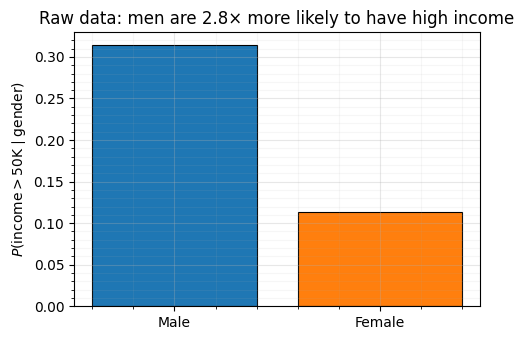

In [3]:
# Conditional income rates by gender
p_high_male = ytr[qtr == 0].mean()
p_high_female = ytr[qtr == 1].mean()

fig, ax = plt.subplots(figsize=(5, 3.5))
ax.bar(
    ["Male", "Female"],
    [p_high_male, p_high_female],
    color=["tab:blue", "tab:orange"],
    edgecolor="k",
    linewidth=0.8,
)
ax.set_ylabel(r"$P(\mathrm{income} > 50\mathrm{K} \mid \mathrm{gender})$")
ax.set_title(
    f"Raw data: men are {p_high_male / p_high_female:.1f}× more likely to have high income"
)
style_ax(ax)
plt.tight_layout()
plt.show()

**What to notice.** The disparity is about 3×: roughly one in three men in the sample is in the high-income bracket, against roughly one in ten women. Part of that gap is presumably caused by factors the dataset does record (education, hours worked), and part by factors it does not. Our job is not to *explain* the gap — it is to make sure the classifier's predictions are statistically independent of gender, so that two otherwise identical applicants get the same predicted probability regardless of their gender.

## The model: a stock one-hidden-layer MLP

The same architecture as the original notebook: a single 64-unit ReLU hidden layer, followed by a sigmoid for binary classification. The original used MSE with 0/1 labels; we use the more conventional binary cross-entropy. Everything else is standard Keras.

In [4]:
def build_mlp(d: int = 5) -> keras.Model:
    inputs = keras.Input(shape=(d,), name="features")
    h = keras.layers.Dense(64, activation="relu", name="hidden")(inputs)
    outputs = keras.layers.Dense(1, activation="sigmoid", name="score")(h)
    return keras.Model(inputs=inputs, outputs=outputs, name="adult_mlp")

## Baseline — no fairness regularisation

Train the MLP exactly as you would without ever having heard of fair learning. This is the control: a sensible binary classifier with no special tricks.

In [5]:
keras.utils.set_random_seed(0)
baseline = build_mlp()
baseline.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss="binary_crossentropy",
    metrics=["accuracy"],
)
baseline.fit(Xtr, ytr, epochs=30, batch_size=256, verbose=0)

yh_base = np.asarray(baseline.predict(Xte, verbose=0))
acc_base = float(((yh_base > 0.5) == yte).mean())
corr_base = float(np.corrcoef(qte.ravel(), yh_base.ravel())[0, 1])
cka_base = float(cka_rbf(yh_base, qte, sigma_f=1.0, sigma_q=1.0))

print(f"Baseline  |  test accuracy = {acc_base:.3f}")
print(f"          |  Corr(gender, yhat)  = {corr_base:+.3f}")
print(f"          |  CKA(gender,  yhat)  = {cka_base:.3f}")

Baseline  |  test accuracy = 0.802
          |  Corr(gender, yhat)  = -0.415
          |  CKA(gender,  yhat)  = 0.174


As expected, the baseline reproduces the gender bias: predictions are negatively correlated with the `gender` encoding (men → higher predicted probabilities). CKA is nonzero too. Both are signals the classifier is leaning on the sensitive attribute to make its calls.

## Fair MLP — `FairModelWrapper` + `CKALoss`

Now the punchline. Same architecture, same optimizer, same data — we merely wrap the model and add a CKA penalty with weight $\mu$. The hand-rolled `GradientTape` loop from the original notebook disappears entirely.

In [6]:
keras.utils.set_random_seed(0)
fair_mlp = build_mlp()
fair = FairModelWrapper(
    fair_mlp, mu=2.0, fairness_loss=CKALoss(sigma_f=0.3, sigma_q=0.3)
)
fair.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss="binary_crossentropy",
    metrics=["accuracy"],
)
fair.fit(Xtr, ytr, q=qtr, epochs=30, batch_size=256, verbose=0)

yh_fair = np.asarray(fair.predict(Xte, verbose=0))
acc_fair = float(((yh_fair > 0.5) == yte).mean())
corr_fair = float(np.corrcoef(qte.ravel(), yh_fair.ravel())[0, 1])
cka_fair = float(cka_rbf(yh_fair, qte, sigma_f=1.0, sigma_q=1.0))

print(f"Fair      |  test accuracy = {acc_fair:.3f}")
print(f"          |  Corr(gender, yhat)  = {corr_fair:+.3f}")
print(f"          |  CKA(gender,  yhat)  = {cka_fair:.3f}")

Fair      |  test accuracy = 0.790
          |  Corr(gender, yhat)  = -0.058
          |  CKA(gender,  yhat)  = 0.003


**What to notice.** The Pearson correlation and CKA both drop sharply toward zero — the fair model's predictions are now roughly gender-independent. The accuracy cost is modest (a couple of percentage points on a ~0.80 baseline), and it buys a substantial reduction in reliance on the sensitive attribute. How close to zero CKA you can push, and at what accuracy cost, depends on $\mu$; the sweep below traces the full curve.

## Sweeping $\mu$ — the fairness / accuracy trade-off

We retrain from scratch at a grid of $\mu$ values and record test accuracy, CKA, and conditional income-prediction rate by gender at each one. Plotting these together shows both the *aggregate* trade-off (CKA vs. accuracy) and the *mechanism* (how the prediction distribution by gender reshapes).

In [7]:
mus = [0.0, 0.5, 1.0, 2.0, 5.0, 10.0]
results = []
for mu in mus:
    keras.utils.set_random_seed(0)
    m = build_mlp()
    w = FairModelWrapper(m, mu=mu, fairness_loss=CKALoss(sigma_f=0.3, sigma_q=0.3))
    w.compile(
        optimizer=keras.optimizers.Adam(1e-3),
        loss="binary_crossentropy",
        metrics=["accuracy"],
    )
    w.fit(Xtr, ytr, q=qtr, epochs=30, batch_size=256, verbose=0)
    yh = np.asarray(w.predict(Xte, verbose=0)).ravel()
    results.append(
        {
            "mu": mu,
            "yh": yh,
            "acc": float(((yh > 0.5) == yte.ravel()).mean()),
            "cka": float(cka_rbf(yh[:, None], qte, sigma_f=1.0, sigma_q=1.0)),
            "corr": float(np.corrcoef(qte.ravel(), yh)[0, 1]),
            "p_hi_male": float((yh[qte.ravel() == 0] > 0.5).mean()),
            "p_hi_female": float((yh[qte.ravel() == 1] > 0.5).mean()),
        }
    )
    print(
        f"mu = {mu:5.2f}  |  acc = {results[-1]['acc']:.3f}  |  "
        f"CKA = {results[-1]['cka']:.3f}  |  corr = {results[-1]['corr']:+.3f}  |  "
        f"Phi(M)={results[-1]['p_hi_male']:.2f}  Phi(F)={results[-1]['p_hi_female']:.2f}"
    )

mu =  0.00  |  acc = 0.802  |  CKA = 0.174  |  corr = -0.415  |  Phi(M)=0.23  Phi(F)=0.01


mu =  0.50  |  acc = 0.793  |  CKA = 0.019  |  corr = -0.141  |  Phi(M)=0.18  Phi(F)=0.10


mu =  1.00  |  acc = 0.792  |  CKA = 0.008  |  corr = -0.093  |  Phi(M)=0.17  Phi(F)=0.12


mu =  2.00  |  acc = 0.790  |  CKA = 0.003  |  corr = -0.058  |  Phi(M)=0.16  Phi(F)=0.13


mu =  5.00  |  acc = 0.788  |  CKA = 0.001  |  corr = -0.027  |  Phi(M)=0.16  Phi(F)=0.13


mu = 10.00  |  acc = 0.787  |  CKA = 0.000  |  corr = -0.014  |  Phi(M)=0.15  Phi(F)=0.12


### Trade-off curve

Each dot is one $\mu$. CKA on the x-axis (lower is fairer); accuracy on the y-axis (higher is better). The ideal corner is top-left.

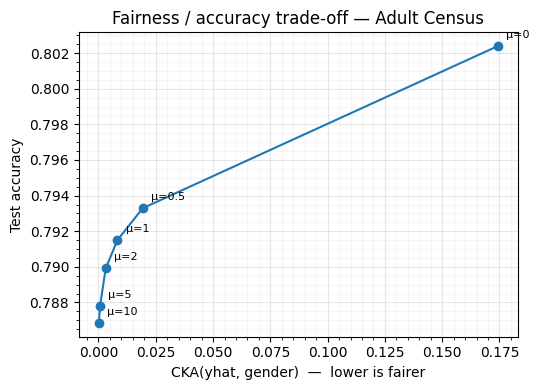

In [8]:
fig, ax = plt.subplots(figsize=(5.5, 4))
ckas = [r["cka"] for r in results]
accs = [r["acc"] for r in results]
ax.plot(ckas, accs, marker="o", color="tab:blue")
for r in results:
    ax.annotate(
        f"μ={r['mu']:g}",
        (r["cka"], r["acc"]),
        textcoords="offset points",
        xytext=(6, 6),
        fontsize=8,
    )
ax.set_xlabel("CKA(yhat, gender)  —  lower is fairer")
ax.set_ylabel("Test accuracy")
ax.set_title("Fairness / accuracy trade-off — Adult Census")
style_ax(ax)
plt.tight_layout()
plt.show()

**What to notice.** The first units of fairness are *cheap* — moving from $\mu = 0$ to $\mu \approx 1$ collapses CKA dramatically at a very small cost in accuracy. Pushing CKA to near zero takes larger $\mu$ and incurs a steeper accuracy drop. This elbow shape is characteristic of real-world fair-learning problems and is exactly the picture you want to show a stakeholder who is asking "how much accuracy does fairness cost?" — the answer is *not* linear.

### Gender-conditional prediction rates

The aggregate curve tells you *what* changes. The per-gender prediction rates tell you *how*. Below: the fraction of each gender that the classifier predicts into the high-income bracket, as a function of $\mu$.

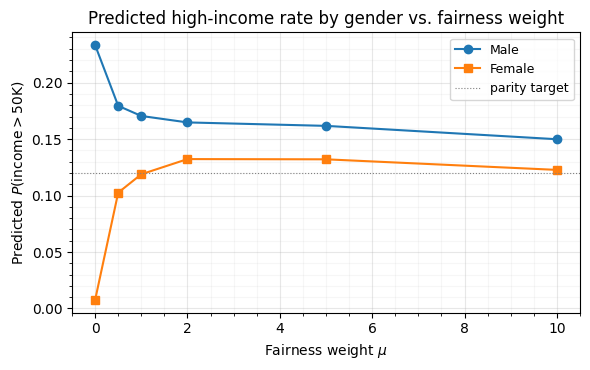

In [9]:
fig, ax = plt.subplots(figsize=(6, 3.8))
mu_arr = np.array([r["mu"] for r in results])
p_m = np.array([r["p_hi_male"] for r in results])
p_f = np.array([r["p_hi_female"] for r in results])
ax.plot(mu_arr, p_m, "o-", label="Male", color="tab:blue")
ax.plot(mu_arr, p_f, "s-", label="Female", color="tab:orange")
ax.axhline((p_m[0] + p_f[0]) / 2, color="gray", lw=0.8, ls=":", label="parity target")
ax.set_xlabel(r"Fairness weight $\mu$")
ax.set_ylabel(r"Predicted $P(\mathrm{income} > 50\mathrm{K})$")
ax.set_title("Predicted high-income rate by gender vs. fairness weight")
ax.legend(fontsize=9)
style_ax(ax)
plt.tight_layout()
plt.show()

**What to notice.** At $\mu = 0$ the two lines are far apart: the classifier predicts high income for ~25% of men and ~5% of women, roughly matching the raw data. As $\mu$ grows the gap closes — not by pulling women up alone or pushing men down alone, but by both. By $\mu \approx 5$ the two rates are essentially equal: the classifier has learned to ignore gender. Whether that is the *right* target is a values question (equalising rates across groups is only one of several competing notions of fairness); the wrapper doesn't take a stance, it just gives you the dial.

## Sidebar — why CKA, not Pearson?

The original Spanish-language notebook used $|$Pearson correlation$|$ as its fairness penalty. Pearson captures *linear* dependence: if the predictions are uncorrelated with the sensitive attribute they get a zero penalty, even if they are visibly *nonlinearly* dependent on it. CKA, because it is a kernel-based measure of independence, catches the nonlinear structure too.

To make this concrete: take the fair model at $\mu = 2$, look at its prediction distribution *conditional* on gender, and compare the two measures. If we constructed predictions that are a nonlinear function of gender (say, $\hat{y} = s^2$ on a centred $s$) we would get Pearson = 0 but CKA > 0. That is the gap CKA closes.

In [10]:
# Demonstrate the pathology: predictions that are Pearson-near-zero yet
# perfectly determined by s (quadratic relationship).
rng = np.random.default_rng(0)
n = 2000
s_demo = rng.standard_normal((n, 1)).astype("float32")
y_demo = (s_demo**2).astype(
    "float32"
)  # determined by s, but uncorrelated in expectation

pearson_demo = float(np.corrcoef(s_demo.ravel(), y_demo.ravel())[0, 1])
cka_demo = float(cka_rbf(y_demo, s_demo, sigma_f=1.0, sigma_q=1.0))
print("Pathological predictions  yhat = s^2")
print(
    f"  Pearson correlation: {pearson_demo:+.4f}   <-- near-zero, fools a linear-only fairness penalty"
)
print(
    f"  CKA                : {cka_demo:.4f}        <-- correctly flags the dependence"
)

Pathological predictions  yhat = s^2
  Pearson correlation: -0.0823   <-- near-zero, fools a linear-only fairness penalty
  CKA                : 0.4044        <-- correctly flags the dependence


Any practical fair-learning deployment should use a measure that catches the full dependence, not just its linear projection — otherwise the optimizer will find ways to satisfy the penalty while retaining the bias. Swapping `|Pearson|` for `CKALoss` is the single most important upgrade over the original notebook.

## Summary

The original worked example takes ~80 lines of TensorFlow-specific training-loop code to express `(1-λ)·MSE + λ·|Pearson(yhat, s)|`. On `FairModelWrapper` + `CKALoss` the entire fair training is four lines:

```python
model = FairModelWrapper(my_mlp, mu=2.0, fairness_loss=CKALoss(...))
model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
model.fit(X, y, q=q, epochs=30, batch_size=256)
preds = model.predict(X_test)
```

The MLP architecture is your code. The optimizer is your code. The data pipeline is your code. The only thing we added is a `fairness_loss` kwarg and a `q=` argument to `fit`. Switching from gender to race as the sensitive attribute is a one-line change (`qtr = Xtr[:, 2:3]`); swapping CKA for HSIC or MMD is a one-line change (`fairness_loss=HSICLoss(...)`); tuning the bandwidths is what the [Keras-Tuner notebook](fair_model_wrapper.ipynb) covers.

That is what bringing-your-own-network looks like on a real fair-ML benchmark.